In [35]:
import numpy as np  
import pandas as pd 
from statsmodels.tsa.seasonal import seasonal_decompose
from matplotlib import pylab
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] =15,6

In [36]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/refs/heads/master/airline-passengers.csv'
df = pd.read_csv(url, header=0, index_col=0, parse_dates=True)
series = df.iloc[:, 0] 
df

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [37]:
#Perform Seasonal deseasonal_decompose
result1 = seasonal_decompose(df, model='multiplicative')

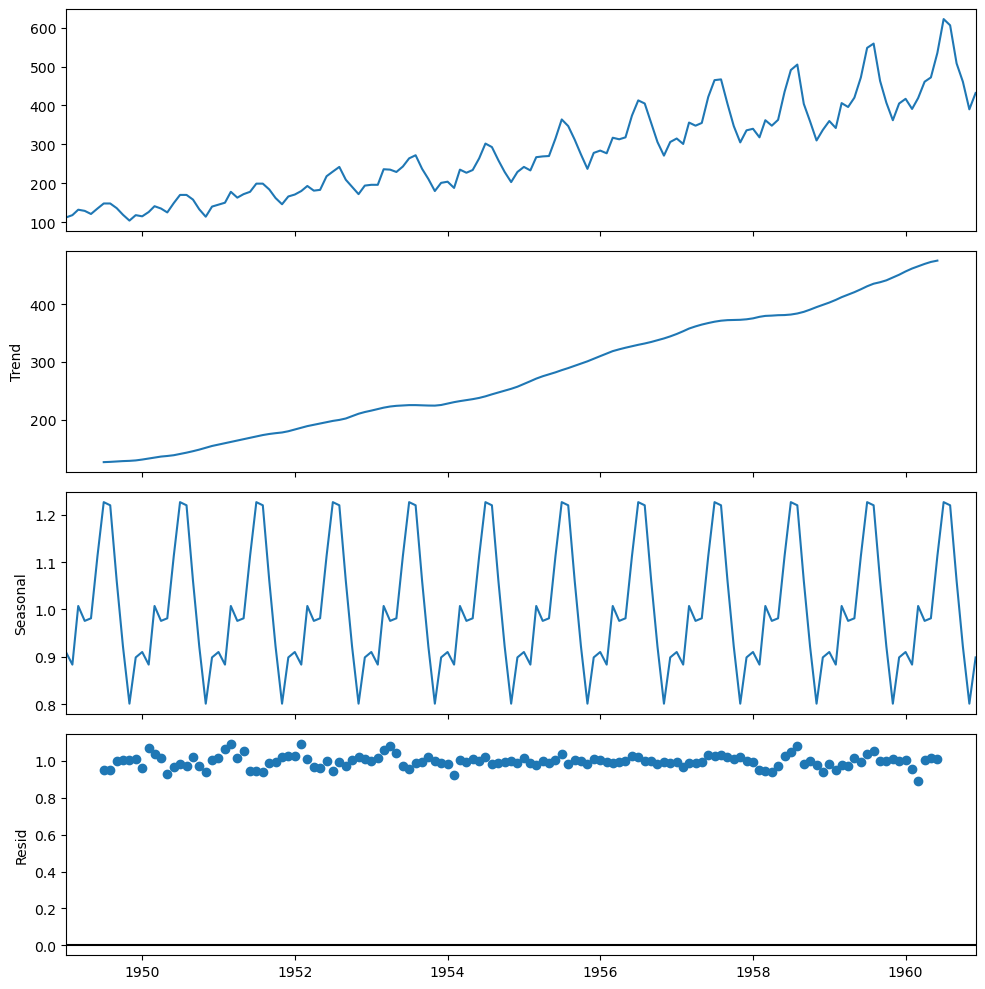

In [38]:
#plot The Components  
plt.rcParams.update({'figure.figsize':(10,10)})
result1.plot()
plt.show()


In [39]:
#Perform Seasonal deseasonal_decompose
result2 = seasonal_decompose(df, model='additive')

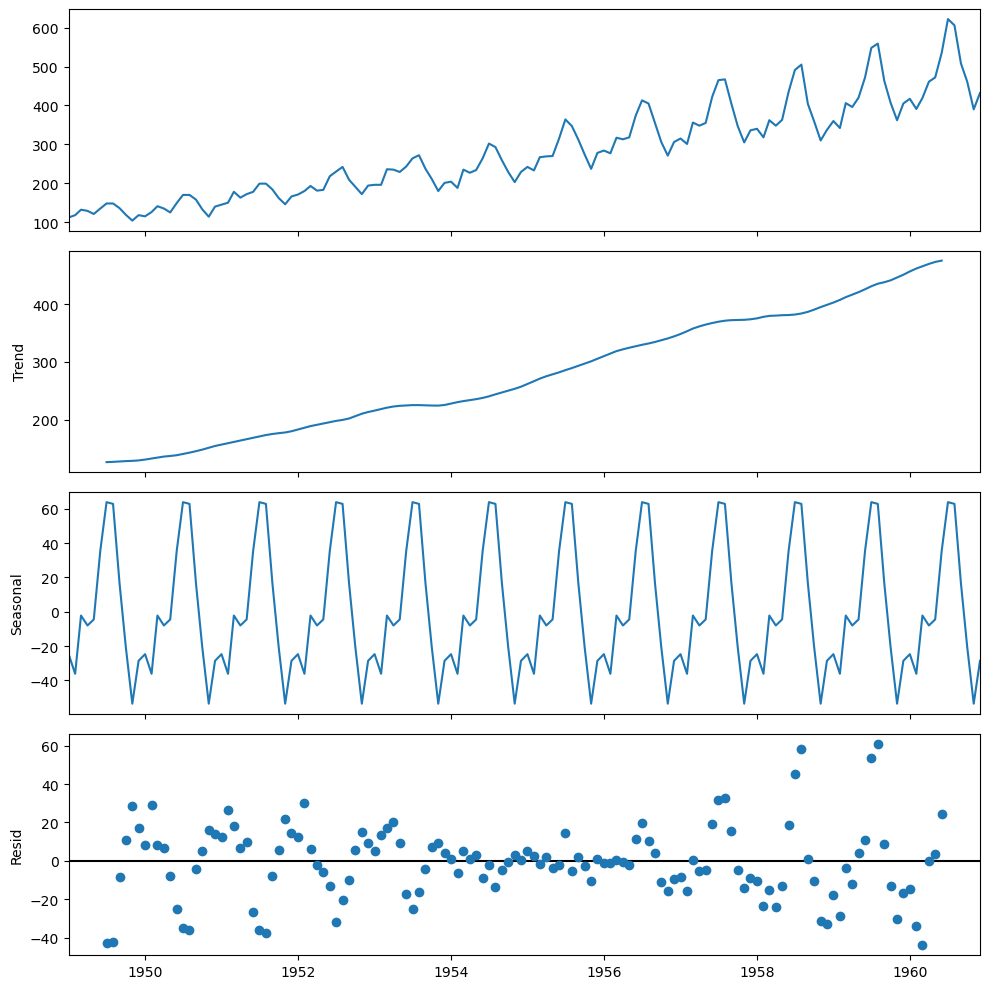

In [40]:
#plot The Components  
plt.rcParams.update({'figure.figsize':(10,10)})
result2.plot()
plt.show()


Missing Value handling

In [41]:
df = pd.read_csv('bank_customer_data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           9607 non-null   object 
 6   Age              9700 non-null   float64
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


Way of finding whether we have null values in the data by using isnull() function 

In [42]:
print(df.isnull().sum())

RowNumber            0
CustomerId           0
Surname              0
CreditScore          0
Geography            0
Gender             393
Age                300
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
dtype: int64


1. Deleting the column with missing values

In [43]:
update_df = df.dropna(axis=1)
update_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Tenure           10000 non-null  int64  
 6   Balance          10000 non-null  float64
 7   NumOfProducts    10000 non-null  int64  
 8   HasCrCard        10000 non-null  int64  
 9   IsActiveMember   10000 non-null  int64  
 10  EstimatedSalary  10000 non-null  float64
 11  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


Deleting the rows with missing data

In [44]:
update_df = df.dropna(axis=0)
update_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9326 entries, 0 to 9699
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        9326 non-null   int64  
 1   CustomerId       9326 non-null   int64  
 2   Surname          9326 non-null   object 
 3   CreditScore      9326 non-null   int64  
 4   Geography        9326 non-null   object 
 5   Gender           9326 non-null   object 
 6   Age              9326 non-null   float64
 7   Tenure           9326 non-null   int64  
 8   Balance          9326 non-null   float64
 9   NumOfProducts    9326 non-null   int64  
 10  HasCrCard        9326 non-null   int64  
 11  IsActiveMember   9326 non-null   int64  
 12  EstimatedSalary  9326 non-null   float64
 13  Exited           9326 non-null   int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


Filling the missing values - imputation

In [45]:
df['Age'].mean()

np.float64(38.574329896907216)

In [46]:
df['Age'].median()

39.0

Fill missing values by mean

In [47]:
update_df = df 
update_df['Age'] = update_df['Age'].fillna(df['Age']).mean()
update_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           9607 non-null   object 
 6   Age              10000 non-null  float64
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


In [48]:
update_df1= df 
update_df1['Age'] = update_df1['Age'].fillna(df['Age']).median()
update_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           9607 non-null   object 
 6   Age              10000 non-null  float64
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


Forword and Backword technique - imputation

In [49]:
df1 = df 
df1['Age']= df1['Age'].bfill()
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           9607 non-null   object 
 6   Age              10000 non-null  float64
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


In [50]:
df1 = df 
df1['Age']= df1['Age'].ffill()
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           9607 non-null   object 
 6   Age              10000 non-null  float64
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


Outlier Handling

3σ rule

In [51]:
data = pd.read_csv('property_data_500.csv')
data.head()

,datesolo,postcode,price,propertyType,bedrooms
0,2007-10-22,2798,550195,house,1
1,2007-02-23,2997,137056,house,3
2,2007-02-18,2642,266480,house,2
3,2007-02-12,2758,372069,house,3
4,2007-10-25,2686,441046,unit,2


In [52]:
type(data)

pandas.core.frame.DataFrame

In [53]:
# Function to detection outlaier on 1dimentional datasets
import statistics
def find_anomolies(data):
    #define a list to accumlate anomalies
    anomalies= []
    # set upper and lowe limit to 3 standart deviation 
    random_data_std = statistics.stdev(data)
    random_data_mean = statistics.mean(data) 

    # 3-standart deviationa
    anomaly_cut_off = random_data_std*3

    lower_limit = random_data_mean - anomaly_cut_off
    upper_limit = random_data_mean + anomaly_cut_off

    # Generate outlier
    for outlier in data:
        if outlier > upper_limit or outlier < lower_limit :
            anomalies.append(outlier) 
    return anomalies
    

In [54]:
data.price

0      550195
1      137056
2      266480
3      372069
4      441046
        ...  
495    236024
496    432940
497    246060
498    244863
499    311238
Name: price, Length: 500, dtype: int64

In [55]:
list1 = find_anomolies(data['price'])

In [56]:
len(list1)

6

In [57]:
len(data)

500

In [58]:
data.price.skew()

np.float64(5.253784870780908)

In [59]:
import seaborn as sns

<Axes: xlabel='price', ylabel='Density'>

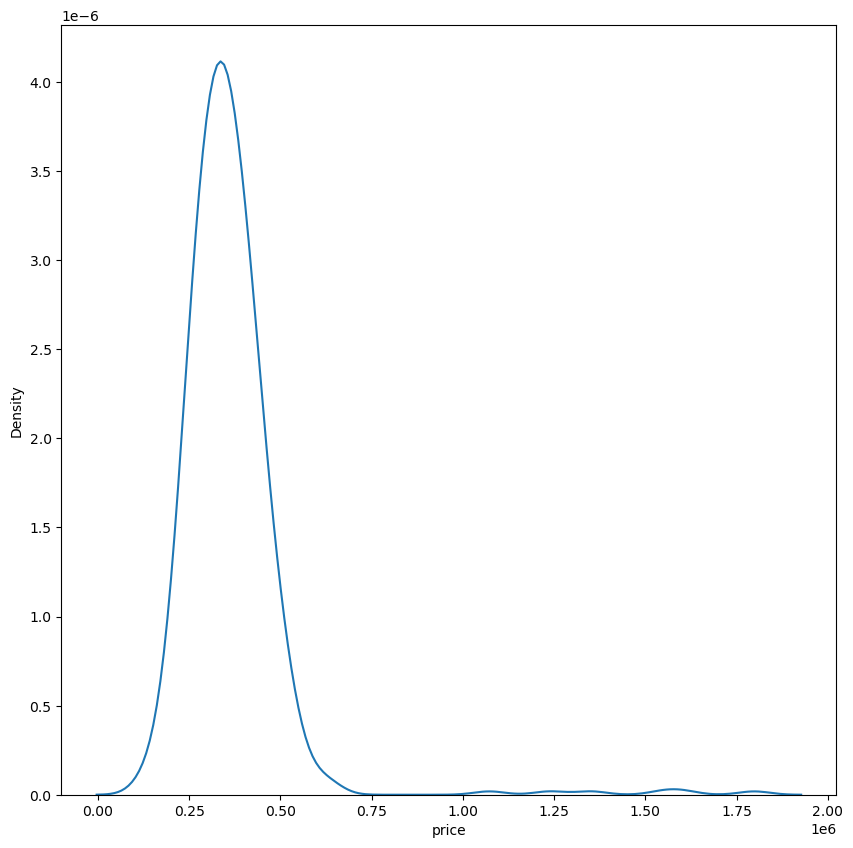

In [60]:
sns.kdeplot(data.price)

In [61]:
data['price_transformed'] = np.log(data.price)
data.price_transformed.skew()

np.float64(0.9201327510650763)

In [62]:
list2 = find_anomolies(data.price_transformed)
len(list2)

8

<Axes: xlabel='price_transformed', ylabel='Density'>

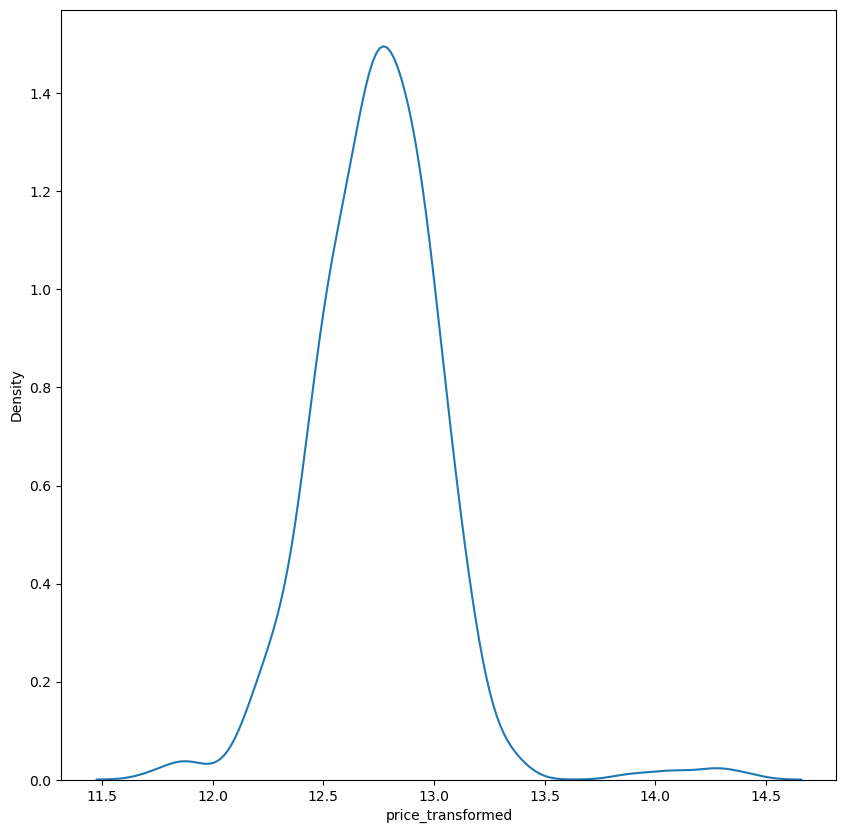

In [63]:
sns.kdeplot(data.price_transformed)

In [64]:
data['price_transformed_double'] = np.log(data.price_transformed)
data.price_transformed_double.skew()

np.float64(0.694745054676883)

In [65]:
list3 = find_anomolies(data.price_transformed_double)
len(list3)

10

<Axes: xlabel='price_transformed_double', ylabel='Density'>

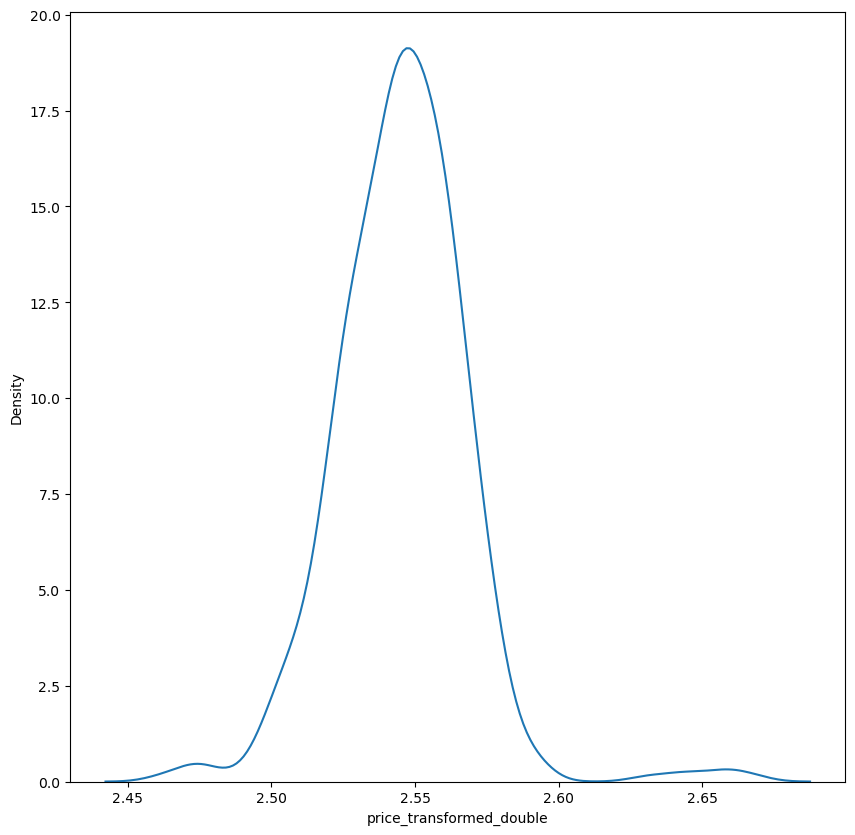

In [66]:
sns.kdeplot(data.price_transformed_double)

Box plots

In [67]:
df = pd.DataFrame(data)
df.describe()

,postcode,price,bedrooms,price_transformed,price_transformed_double
count,500.000000,5.000000e+02,500.000000,500.000000,500.000000
mean,2800.008000,3.628048e+05,3.068000,12.751025,2.545343
std,111.708144,1.481952e+05,1.418238,0.297832,0.023152
min,2601.000000,1.245450e+05,1.000000,11.732422,2.462356
25%,2704.750000,2.878858e+05,2.000000,12.570319,2.531338
50%,2798.000000,3.444720e+05,3.000000,12.749768,2.545513
75%,2891.000000,4.078158e+05,4.000000,12.918571,2.558666
max,2999.000000,1.798684e+06,5.000000,14.402566,2.667406


Model- ARIMA

In [70]:
data_passenger = pd.read_csv('passengers_100.csv')
data_passenger

,Month,#Passengers
0,1949-01,272
1,1949-02,147
2,1949-03,217
3,1949-04,292
4,1949-05,423
...,...,...
95,1956-12,199
96,1957-01,153
97,1957-02,496
98,1957-03,221


In [87]:

data_passenger = pd.read_csv('passengers_100.csv')
data_passenger['Month'] = pd.to_datetime(data_passenger['Month'], format='%Y-%m')
data_passenger.set_index('Month', inplace=True)

print(data_passenger.head())


            #Passengers
Month                  
1949-01-01          272
1949-02-01          147
1949-03-01          217
1949-04-01          292
1949-05-01          423


In [86]:
data_passenger.Month.values

array(['1949-01-01T00:00:00.000000000', '1949-02-01T00:00:00.000000000',
       '1949-03-01T00:00:00.000000000', '1949-04-01T00:00:00.000000000',
       '1949-05-01T00:00:00.000000000', '1949-06-01T00:00:00.000000000',
       '1949-07-01T00:00:00.000000000', '1949-08-01T00:00:00.000000000',
       '1949-09-01T00:00:00.000000000', '1949-10-01T00:00:00.000000000',
       '1949-11-01T00:00:00.000000000', '1949-12-01T00:00:00.000000000',
       '1950-01-01T00:00:00.000000000', '1950-02-01T00:00:00.000000000',
       '1950-03-01T00:00:00.000000000', '1950-04-01T00:00:00.000000000',
       '1950-05-01T00:00:00.000000000', '1950-06-01T00:00:00.000000000',
       '1950-07-01T00:00:00.000000000', '1950-08-01T00:00:00.000000000',
       '1950-09-01T00:00:00.000000000', '1950-10-01T00:00:00.000000000',
       '1950-11-01T00:00:00.000000000', '1950-12-01T00:00:00.000000000',
       '1951-01-01T00:00:00.000000000', '1951-02-01T00:00:00.000000000',
       '1951-03-01T00:00:00.000000000', '1951-04-01

In [89]:
#Convert to time series 
ts = data_passenger['#Passengers']
ts

Month
1949-01-01    272
1949-02-01    147
1949-03-01    217
1949-04-01    292
1949-05-01    423
             ... 
1956-12-01    199
1957-01-01    153
1957-02-01    496
1957-03-01    221
1957-04-01    526
Name: #Passengers, Length: 100, dtype: int64

In [91]:
#Indexing time series arrays  
print(ts['1956-12-01'])

199


In [93]:
#Import dtaetime library and use 'datetime' function 
from datetime import datetime 
print(ts[datetime(1957,1,1)])

153


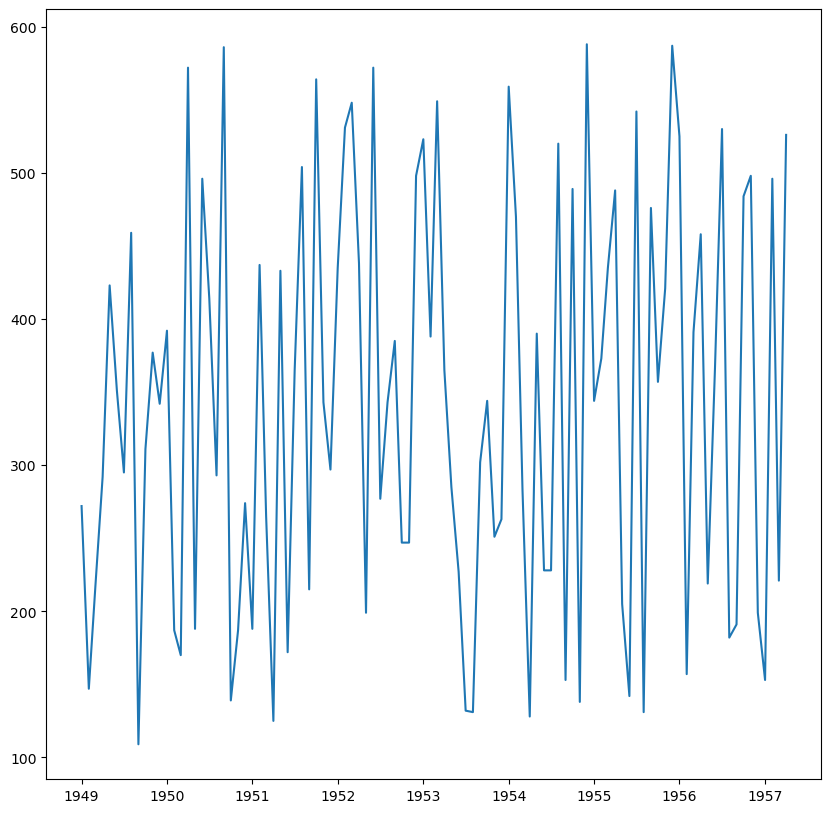

In [94]:
#Check Stationary 
plt.plot(ts)

In [97]:
#Stationary check  
#Ho: TS is non stationary 
#H1: Ts is Stationary 

from statsmodels.tsa.stattools import adfuller 
def test_stationary(timeseries):

    #Determining Rooling Sstatistics
    #rolmean = pd.rolling_mean(timeseries, window=12)
    rolmean = pd.Series(timeseries).rolling(window=12).mean()
    #rolstd = pd.rollind_std(timeseries, window=12)
    rolstd = pd.Series(timeseries).rolling(window=12).std()

    #Plot rolling statistics
    orig = plt.plot(timeseries, color ='blue', label= 'Original')
    mean = plt.plot(rolmean, color ='red', label= 'Rolling Mean')
    std = plt.plot(timeseries, color ='black', label= 'Rolling Std')
    plt.legend(loc = 'best')
    plt.title('Rolling Mean and Standard Deviation')
    plt.show(block=False)

    #Perform Dickey-Fuller Test 
    print("Result of Dickey-Fuller Test: ")
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index = ['Test Statistics' , 'P-value', '#Lags Used', 'Number of Observation Used'])

    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' %key] = value
    print(dfoutput)
    

    

In [98]:
ts

Month
1949-01-01    272
1949-02-01    147
1949-03-01    217
1949-04-01    292
1949-05-01    423
             ... 
1956-12-01    199
1957-01-01    153
1957-02-01    496
1957-03-01    221
1957-04-01    526
Name: #Passengers, Length: 100, dtype: int64

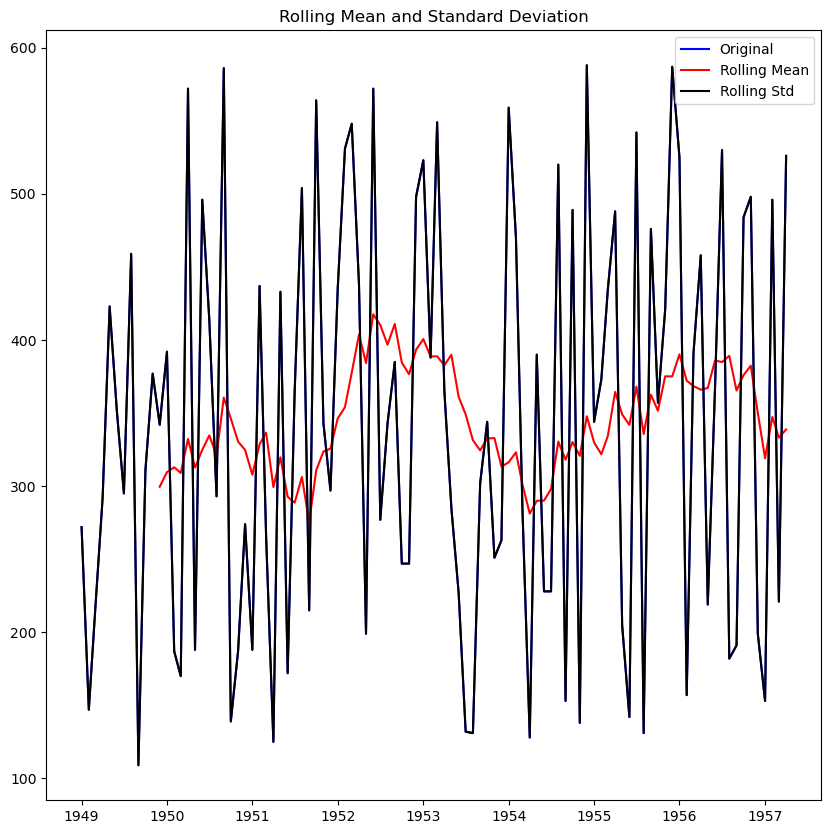

Result of Dickey-Fuller Test: 
Test Statistics              -1.140993e+01
P-value                       7.292400e-21
#Lags Used                    0.000000e+00
Number of Observation Used    9.900000e+01
Critical Value (1%)          -3.498198e+00
Critical Value (5%)          -2.891208e+00
Critical Value (10%)         -2.582596e+00
dtype: float64


In [99]:
test_stationary(ts)